# Requirements
#### **(Preferred: make each one of requirment in md cell then your answer te be more organized.)**
#### **(Note: You can use another image, but upload it so I can see the original one.)**
### 1. Load the Image

* Read the image.
* Display the original image.
* Print its width, height, and number of channels.

---

### 2. Image Preprocessing

Improve the image quality by applying suitable preprocessing techniques such as:

* Grayscale conversion
* Noise reduction
* Image sharpening (if needed)
* Contrast enhancement

---

### 3. Edge Detection

Detect the major edges in the image using an appropriate method.

Display the detected edges.

---

### 4. Detect the Document

Locate the document inside the image.

Draw its contour on the original image.

---

### 5. Perspective Correction

Apply a Perspective Transform to obtain a top-down scanned version of the document.

---

### 6. Produce a Scanned Document

Generate a clean black-and-white scanned image using suitable thresholding techniques.

---

### 7. Contour Analysis

Extract all significant contours from the processed image.

For each contour:

* Draw its bounding rectangle.
* Display its area.
* Ignore very small contours.

---

### 8. Shape Detection

Detect and classify simple geometric shapes whenever possible.

Examples:

* Rectangle
* Square
* Circle
* Triangle

---

### 9. Histogram Analysis

Display the image histogram.

Briefly explain what the histogram indicates about the image.

---

### 10. Color Space Analysis

Convert the image into at least **two different color spaces**.

Explain why each color space could be useful.

---

### 11. Image Comparison

Compare:

* Original image
* Final processed image

Use:

* MSE
* SSIM

Comment on the obtained values.

---

### 12. Final Visualization

Create one final image showing:

* Document boundary
* Corner points
* Bounding boxes
* Any detected shapes
* Labels

---

# Bonus (Optional)

Implement any **three** of the following:

* Automatic image rotation.
* Automatic brightness correction.
* Shadow removal.
* Line detection using Hough Transform.
* Corner detection.
* Template Matching.
* Dominant color extraction using K-Means.
* Object counting.
* OCR-ready preprocessing.

Width : 513
Height: 385
Channels: 3


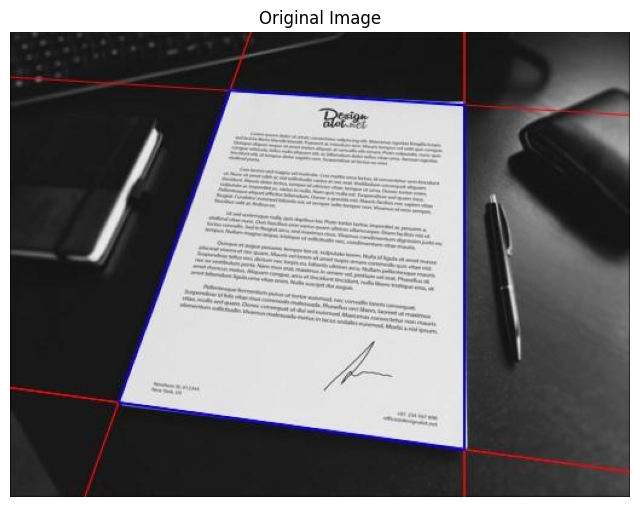

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Change this path to your image
image_path = "/content/Task.jpeg"

image = cv2.imread(image_path)

# OpenCV loads BGR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width, channels = image.shape

print(f"Width : {width}")
print(f"Height: {height}")
print(f"Channels: {channels}")

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

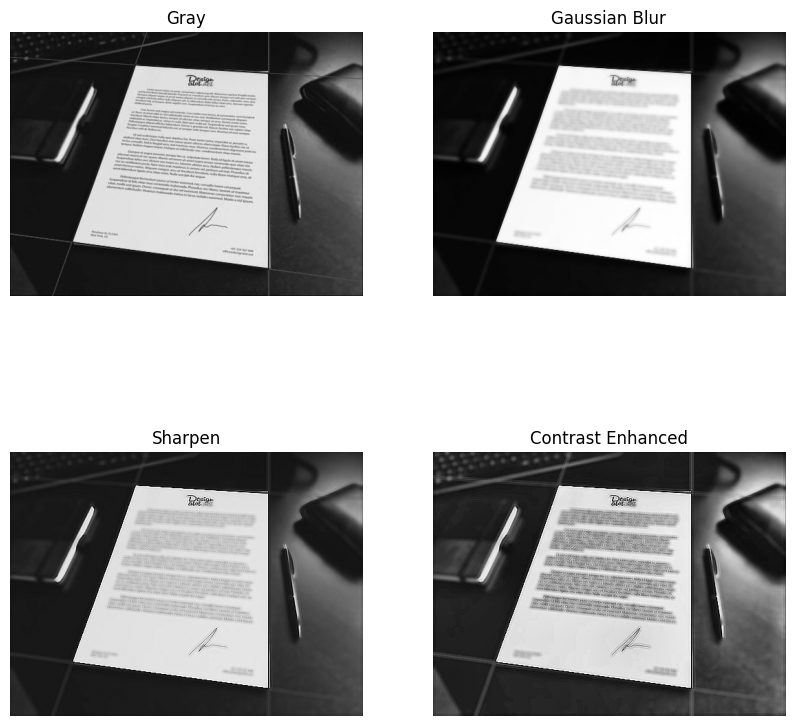

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.bilateralFilter(gray, 9, 75, 75)

kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

sharpen = cv2.filter2D(blur, -1, kernel)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced = clahe.apply(sharpen)

fig, ax = plt.subplots(2,2, figsize=(10,10))

ax[0,0].imshow(gray,cmap="gray")
ax[0,0].set_title("Gray")

ax[0,1].imshow(blur,cmap="gray")
ax[0,1].set_title("Gaussian Blur")

ax[1,0].imshow(sharpen,cmap="gray")
ax[1,0].set_title("Sharpen")

ax[1,1].imshow(enhanced,cmap="gray")
ax[1,1].set_title("Contrast Enhanced")

for a in ax.ravel():
    a.axis("off")

plt.show()

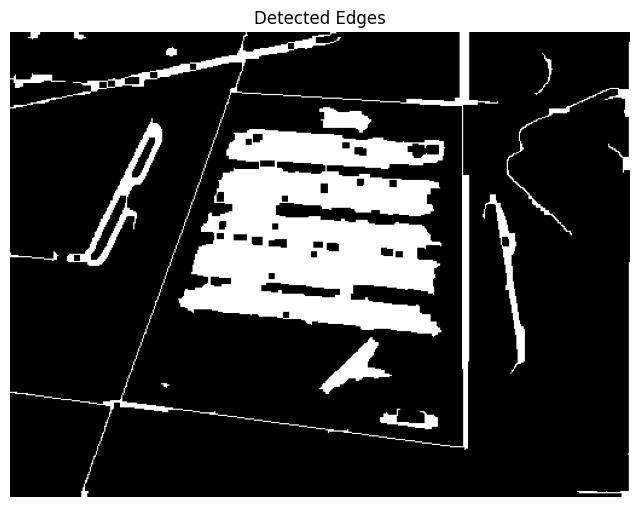

In [ ]:
edges = cv2.Canny(enhanced, 75, 200)

kernel = np.ones((5,5), np.uint8)

edges = cv2.dilate(edges, kernel, iterations=1)
edges = cv2.erode(edges, kernel, iterations=1)

plt.figure(figsize=(8,8))
plt.imshow(edges, cmap="gray")
plt.title("Detected Edges")
plt.axis("off")
plt.show()

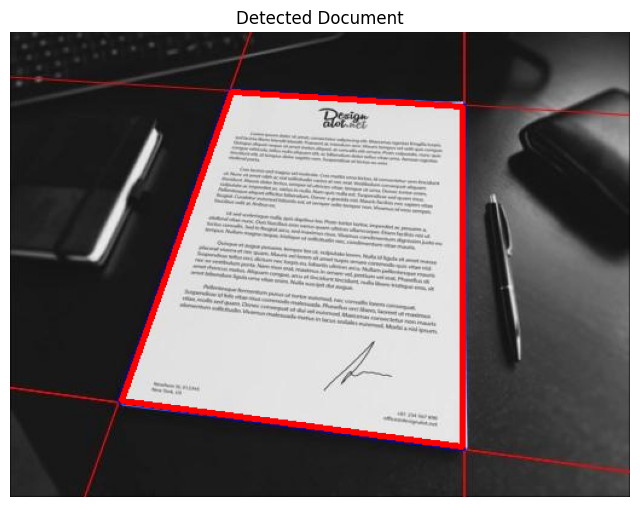

In [ ]:
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_LIST,
    cv2.CHAIN_APPROX_SIMPLE
)

contours = sorted(
    contours,
    key=cv2.contourArea,
    reverse=True
)[:10]

document = None

for c in contours:

    perimeter = cv2.arcLength(c, True)

    approx = cv2.approxPolyDP(
        c,
        0.015 * perimeter,
        True
    )

    if len(approx) == 4:
        document = approx
        break

document_image = image_rgb.copy()

if document is not None:

    cv2.drawContours(
        document_image,
        [document],
        -1,
        (255,0,0),
        4
    )

plt.figure(figsize=(8,8))
plt.imshow(document_image)
plt.title("Detected Document")
plt.axis("off")
plt.show()

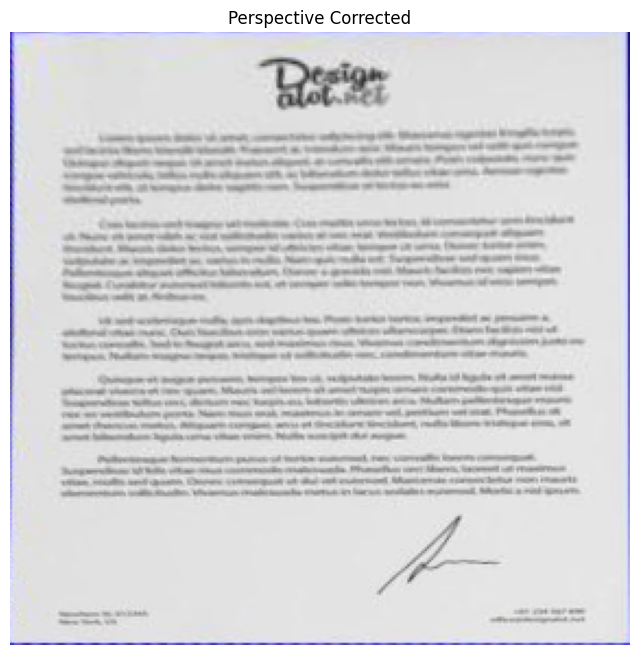

In [ ]:
def order_points(pts):
    pts = pts.reshape(4, 2).astype("float32")

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)

    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]

    top_right = pts[np.argmin(diff)]
    bottom_left = pts[np.argmax(diff)]

    return np.array([
        top_left,
        top_right,
        bottom_right,
        bottom_left
    ], dtype="float32")


if document is None:
    raise Exception("Document was not detected.")

rect = order_points(document)

(tl, tr, br, bl) = rect

widthA = np.linalg.norm(br - bl)
widthB = np.linalg.norm(tr - tl)
maxWidth = int(max(widthA, widthB))

heightA = np.linalg.norm(tr - br)
heightB = np.linalg.norm(tl - bl)
maxHeight = int(max(heightA, heightB))

destination = np.array([
    [0, 0],
    [maxWidth - 1, 0],
    [maxWidth - 1, maxHeight - 1],
    [0, maxHeight - 1]
], dtype="float32")

M = cv2.getPerspectiveTransform(rect, destination)

warped = cv2.warpPerspective(
    image,
    M,
    (maxWidth, maxHeight)
)

warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,10))
plt.imshow(warped_rgb)
plt.title("Perspective Corrected")
plt.axis("off")
plt.show()

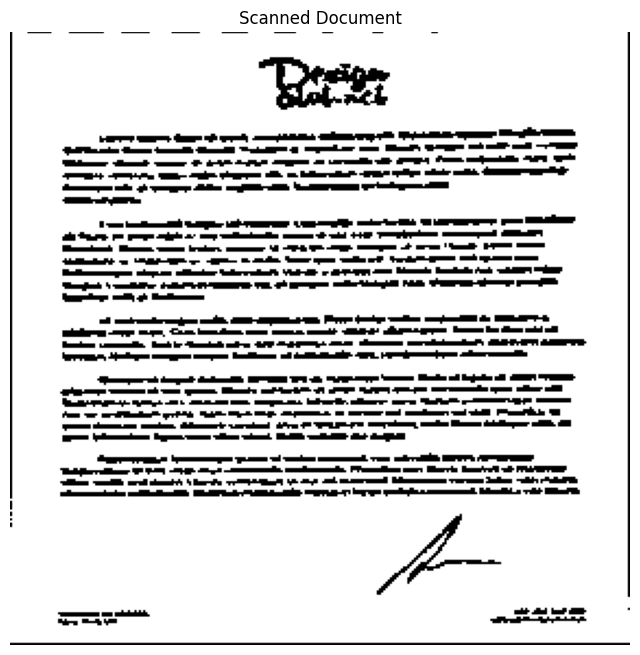

In [ ]:
warped_gray = cv2.cvtColor(
    warped,
    cv2.COLOR_BGR2GRAY
)

scanned = cv2.adaptiveThreshold(
    warped_gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    21,
    15
)

plt.figure(figsize=(8,10))
plt.imshow(scanned, cmap="gray")
plt.title("Scanned Document")
plt.axis("off")
plt.show()

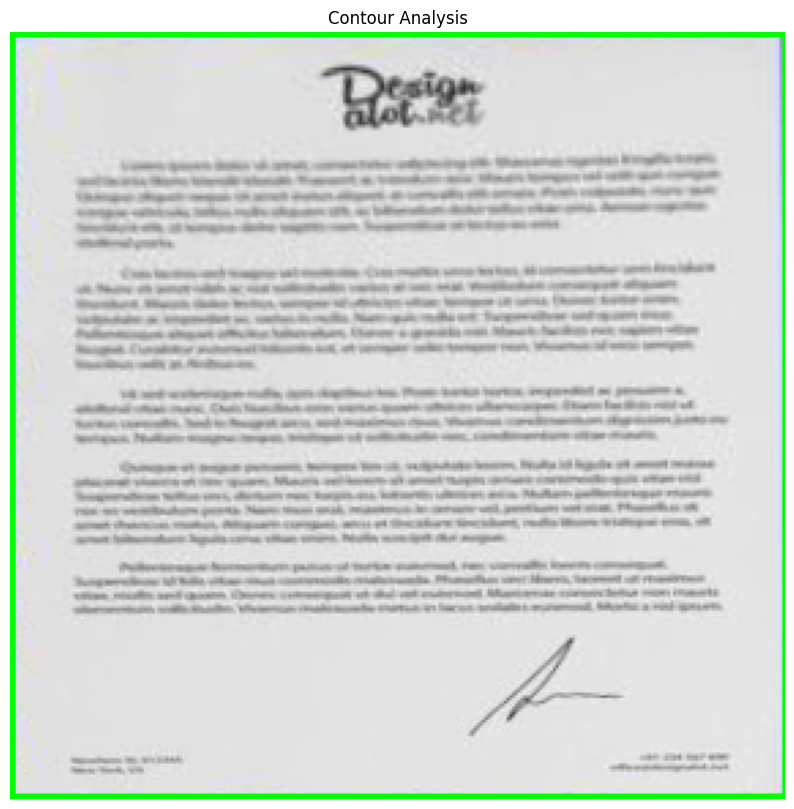

In [ ]:
contours, _ = cv2.findContours(
    scanned.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result = warped_rgb.copy()

minimum_area = 1000

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area < minimum_area:
        continue

    x, y, w, h = cv2.boundingRect(cnt)

    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        result,
        f"{int(area)}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(result)
plt.title("Contour Analysis")
plt.axis("off")
plt.show()

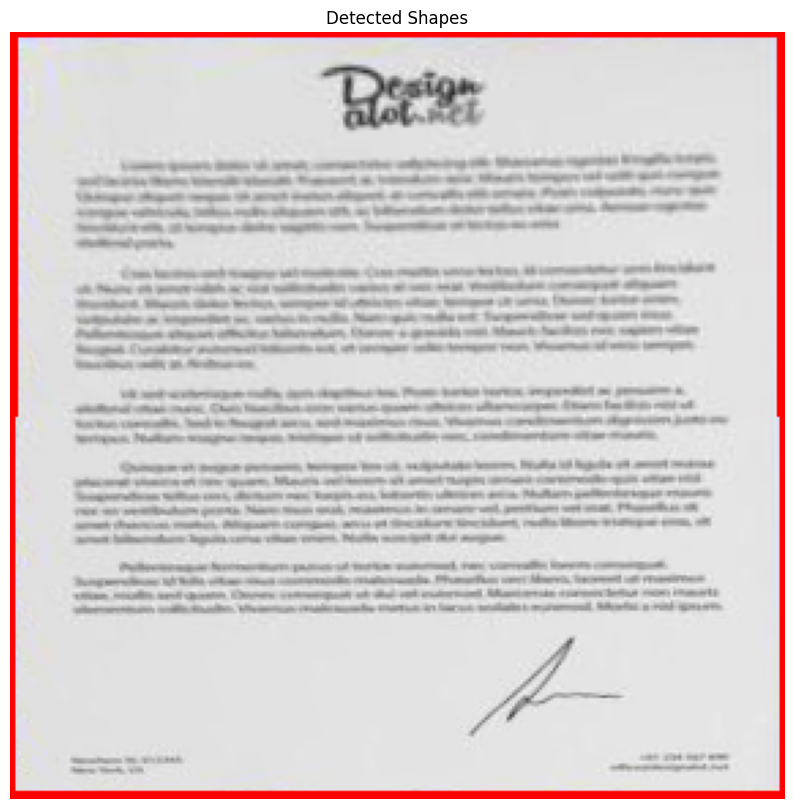

In [ ]:
shape_image = warped_rgb.copy()

contours, _ = cv2.findContours(
    scanned.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area < 1000:
        continue

    perimeter = cv2.arcLength(cnt, True)

    approx = cv2.approxPolyDP(
        cnt,
        0.04 * perimeter,
        True
    )

    vertices = len(approx)

    x, y, w, h = cv2.boundingRect(approx)

    # Avoid division by zero
    if min(w, h) == 0 or perimeter == 0:
        continue

    aspect_ratio = max(w, h) / float(min(w, h))
    circularity = (4 * np.pi * area) / (perimeter * perimeter)

    if aspect_ratio > 3:
        continue

    if circularity < 0.5 and vertices > 6:
        continue

    # Shape classification
    if aspect_ratio > 4:
        shape = "Line"

    elif vertices == 3:
        shape = "Triangle"

    elif vertices == 4:
        ratio = w / float(h)

        if 0.95 <= ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    elif circularity > 0.80:
        shape = "Circle"

    else:
        shape = "Polygon"

    cv2.drawContours(
        shape_image,
        [approx],
        -1,
        (255, 0, 0),
        2
    )

    cv2.putText(
        shape_image,
        shape,
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(shape_image)
plt.title("Detected Shapes")
plt.axis("off")
plt.show()

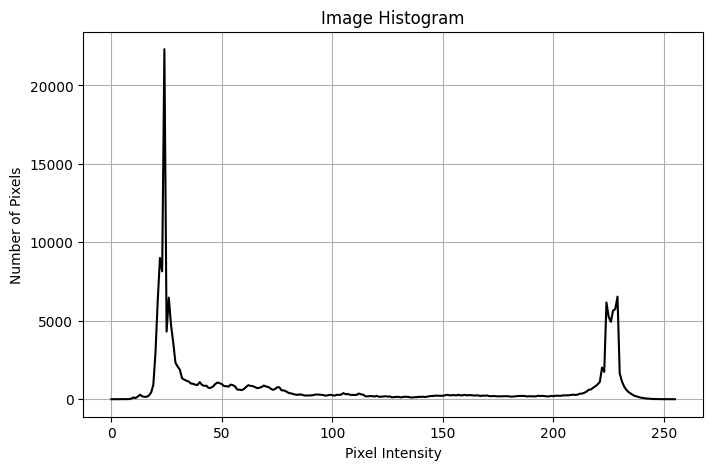

Histogram Interpretation:
- Peaks indicate the most common pixel intensities.
- A wide distribution usually means better contrast.
- A narrow distribution suggests low contrast.


In [ ]:
gray_original = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

hist = cv2.calcHist(
    [gray_original],
    [0],
    None,
    [256],
    [0, 256]
)

plt.figure(figsize=(8,5))
plt.plot(hist, color="black")
plt.title("Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.grid(True)
plt.show()

print("Histogram Interpretation:")
print("- Peaks indicate the most common pixel intensities.")
print("- A wide distribution usually means better contrast.")
print("- A narrow distribution suggests low contrast.")

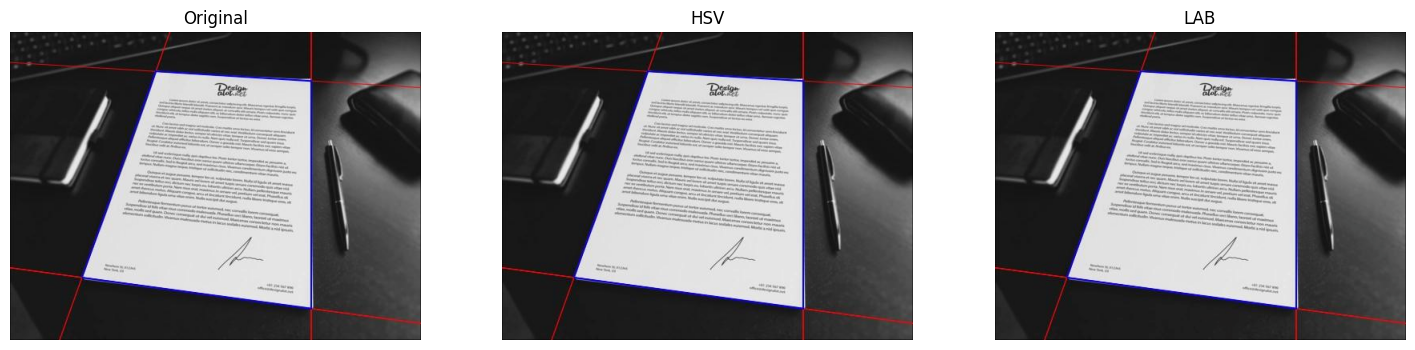

HSV:
- Separates Hue, Saturation, and Value.
- Useful for color segmentation.

LAB:
- Separates brightness from color.
- Useful for illumination correction.


In [ ]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(image_rgb)
ax[0].set_title("Original")

ax[1].imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
ax[1].set_title("HSV")

ax[2].imshow(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))
ax[2].set_title("LAB")

for a in ax:
    a.axis("off")

plt.show()

print("HSV:")
print("- Separates Hue, Saturation, and Value.")
print("- Useful for color segmentation.")

print()

print("LAB:")
print("- Separates brightness from color.")
print("- Useful for illumination correction.")

MSE  : 29568.92
SSIM : 0.1445


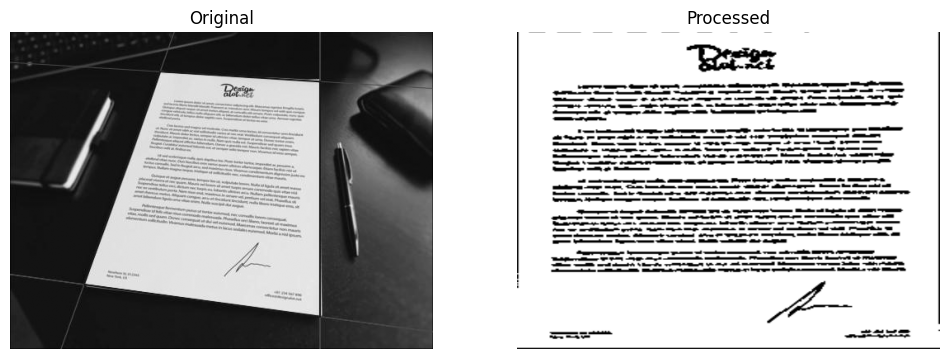


Interpretation:
- High MSE indicates noticeable pixel differences.
- Low structural similarity.


In [ ]:
from skimage.metrics import structural_similarity as ssim

original_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

processed_resized = cv2.resize(
    scanned,
    (
        original_gray.shape[1],
        original_gray.shape[0]
    )
)

mse = np.mean(
    (original_gray.astype("float") -
     processed_resized.astype("float")) ** 2
)

ssim_score, _ = ssim(
    original_gray,
    processed_resized,
    full=True
)

print(f"MSE  : {mse:.2f}")
print(f"SSIM : {ssim_score:.4f}")

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(original_gray, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(processed_resized, cmap="gray")
ax[1].set_title("Processed")

for a in ax:
    a.axis("off")

plt.show()

print("\nInterpretation:")

if mse < 1000:
    print("- Low MSE indicates small pixel differences.")
else:
    print("- High MSE indicates noticeable pixel differences.")

if ssim_score > 0.8:
    print("- High SSIM indicates the document structure is well preserved.")
elif ssim_score > 0.5:
    print("- Moderate structural similarity.")
else:
    print("- Low structural similarity.")

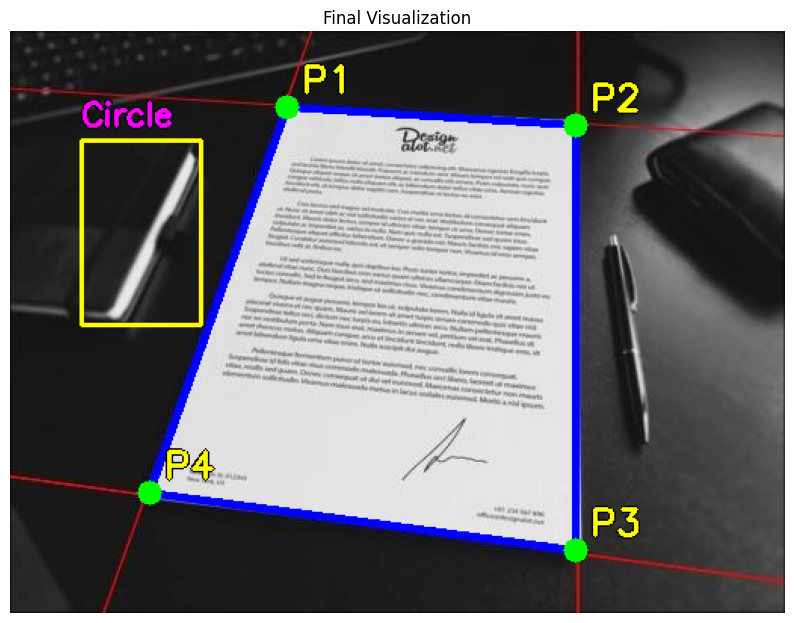

In [ ]:
final_image = image_rgb.copy()

# Draw the detected document
if document is not None:

    cv2.drawContours(
        final_image,
        [document],
        -1,
        (0, 0, 255),   # Red
        3
    )

    for i, point in enumerate(document):

        x, y = point[0]

        cv2.circle(
            final_image,
            (x, y),
            8,
            (0, 255, 0),
            -1
        )

        # Black outline
        cv2.putText(
            final_image,
            f"P{i+1}",
            (x+10, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,0,0),
            4
        )

        # Yellow text
        cv2.putText(
            final_image,
            f"P{i+1}",
            (x+10, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255,255,0),
            2
        )

# Detect Shapes
contours, _ = cv2.findContours(
    edges.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

img_h, img_w = image_rgb.shape[:2]

for cnt in contours:

    area = cv2.contourArea(cnt)

    # Ignore tiny contours
    if area < 1000:
        continue

    # Ignore contour around the whole image
    if area > 0.9 * img_h * img_w:
        continue

    x, y, w, h = cv2.boundingRect(cnt)

    # Ignore image border
    if w > 0.95 * img_w and h > 0.95 * img_h:
        continue

    perimeter = cv2.arcLength(cnt, True)

    approx = cv2.approxPolyDP(
        cnt,
        0.02 * perimeter,
        True
    )

    vertices = len(approx)

    aspect_ratio = max(w, h) / float(min(w, h))

    # Shape classification
    if aspect_ratio > 4:
        shape = "Line"

    elif vertices == 3:
        shape = "Triangle"

    elif vertices == 4:

        ratio = w / float(h)

        if 0.95 <= ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    elif vertices > 6:
        shape = "Circle"

    else:
        shape = "Polygon"

    # Skip the detected document (already drawn)
    if document is not None:

        if cv2.contourArea(cnt) > 0.6 * cv2.contourArea(document):
            continue

    cv2.rectangle(
        final_image,
        (x, y),
        (x+w, y+h),
        (255,255,0),
        2
    )

    # Black outline
    cv2.putText(
        final_image,
        shape,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0,0,0),
        4
    )

    # Magenta text
    cv2.putText(
        final_image,
        shape,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,0,255),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(final_image)
plt.title("Final Visualization")
plt.axis("off")
plt.show()